In [1]:
import numpy as np
import cv2
import os
from PIL import Image, ImageDraw
from skimage.feature import graycomatrix, graycoprops, hog
from skimage.color import rgb2gray
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.utils import shuffle
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np

def split_train_test(data, train_size=6000):
    """
    Split dataset into train and test sets.

    Parameters:
    -----------
    data : np.ndarray
        Full dataset
    train_size : int
        Number of rows for training

    Returns:
    --------
    X_train, y_train, X_test, y_test
    """

    train = data[:train_size]
    test = data[train_size:]

    X_train = train[:, :-1]
    y_train = train[:, -1]

    X_test = test[:, :-1]
    y_test = test[:, -1]

    return X_train, y_train, X_test, y_test

# _________________________________________________ Test Stage _____________________________________________
# _________________________________________Load Feature Extraction Vectores ________________________________
# ____________________________________ hog or glcm or orb , vgg , yolo , resnet ____________________________


In [3]:
# load Feature Extraction Vectors (hog, glcm, orb, vgg, yolo, squeezenet, resnet, ML, DL, ALL)
import numpy as np

# Set feature_type to one of: 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'squeezenet', 'resnet'
feature_type = 'all'  # Change to 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'squeezenet, 'resnet' as needed

features_array = None

if feature_type == 'all':
    df = pd.read_csv('hormany_FS/all_features_array.csv')
    print("Loaded ALL features (ML + DL).")
elif feature_type == 'ml':
    df = pd.read_csv('hormany_FS/combined_ML_features_array.csv')
    print("Loaded ML features.")
elif feature_type == 'dl':
    df = pd.read_csv('hormany_FS/combined_DL_features_array.csv')
    print("Loaded DL features.")
elif feature_type == 'hog':
    df = pd.read_csv('hormany_FS/hog_features_array.csv')
    print("Loaded HOG features.")
elif feature_type == 'glcm':
    df = pd.read_csv('hormany_FS/glcm_features_array.csv')
    print("Loaded GLCM features.")
elif feature_type == 'orb':
    df = pd.read_csv('hormany_FS/orb_features_array.csv')
    print("Loaded ORB features.")
elif feature_type == 'vgg':
    df = pd.read_csv('hormany_FS/vgg_features_array.csv')
    print("Loaded VGG features.")
elif feature_type == 'resnet':
    df = pd.read_csv('hormany_FS/resnet_features_array.csv')
    print("Loaded ResNet features.")
elif feature_type == 'squeezenet':
    df = pd.read_csv('hormany_FS/squeezenet_features_array.csv')
    print("Loaded squeezenet features.")
elif feature_type == 'yolo':
    df = pd.read_csv('hormany_FS/yolo_features_array.csv')
    print("Loaded YOLO features.")
else:
    raise ValueError("Invalid feature_type. Choose from 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'squeezenet', 'resnet'.")
# Separate features and labels
features_array = df.drop('label', axis=1).values
labels_array = df['label'].values

print('Features shape:', features_array.shape)
print('Labels shape:', labels_array.shape)

print(f"------++++++++ Load Feature Extraction Vectors is Done :- {feature_type} +++++++++-------------")

Loaded ALL features (ML + DL).
Features shape: (6329, 2446)
Labels shape: (6329,)
------++++++++ Load Feature Extraction Vectors is Done :- all +++++++++-------------


In [4]:
from sklearn.model_selection import train_test_split

X_train, y_train, X_test, y_test = split_train_test(df.values, train_size=6000)

# Print the shapes of the train and test sets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6000, 2446)
X_test shape: (329, 2446)
y_train shape: (6000,)
y_test shape: (329,)


In [12]:
# === إصلاح شامل لمشكلة الأنواع ===
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# 1. نقوم بتدريب المشفر على y_train2 (بعد التضخيم) لأنه يحتوي على جميع الأصناف
le.fit(y_train)

# 2. نقوم بتحويل جميع متغيرات التسميات المستخدمة في الكود
# (هذا هو السطر الذي كان مفقوداً ويسبب الخطأ)
y_train = le.transform(y_train)

# تحويل المتغيرات الأخرى
y_test = le.transform(y_test)

print("تم تحويل جميع المتغيرات (y_train, y_train2, y_test) إلى أرقام بنجاح.")
print(f"الأصناف: {le.classes_}")

تم تحويل جميع المتغيرات (y_train, y_train2, y_test) إلى أرقام بنجاح.
الأصناف: [0 1]



Evaluating RandomForest
Training Accuracy: 0.9998
Test Accuracy: 0.9422


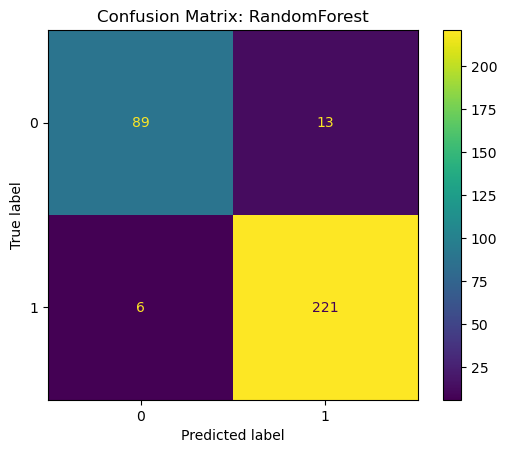

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       102
           1       0.94      0.97      0.96       227

    accuracy                           0.94       329
   macro avg       0.94      0.92      0.93       329
weighted avg       0.94      0.94      0.94       329


Evaluating ExtraTrees
Training Accuracy: 0.9998
Test Accuracy: 0.9453


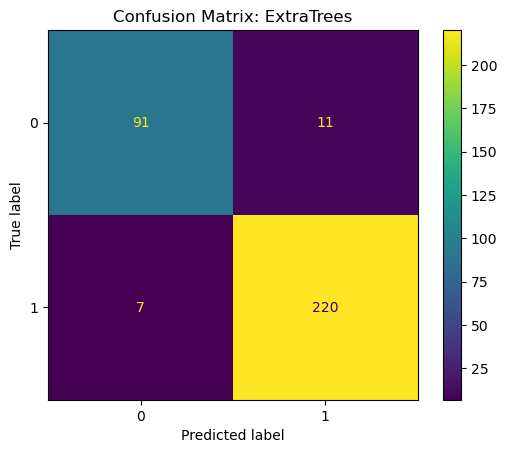

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       102
           1       0.95      0.97      0.96       227

    accuracy                           0.95       329
   macro avg       0.94      0.93      0.94       329
weighted avg       0.94      0.95      0.94       329


Evaluating LogisticRegression


c:\Users\iqmah\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Accuracy: 0.9710
Test Accuracy: 0.9119


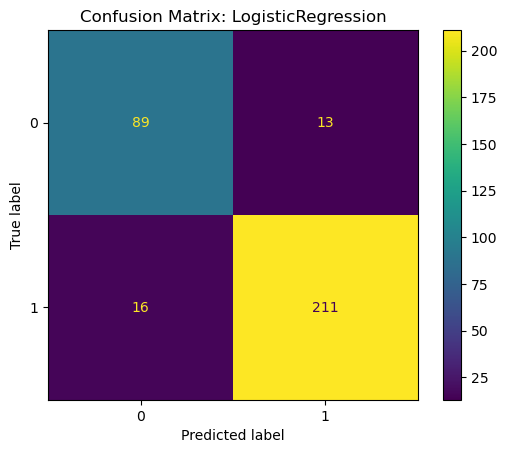

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       102
           1       0.94      0.93      0.94       227

    accuracy                           0.91       329
   macro avg       0.89      0.90      0.90       329
weighted avg       0.91      0.91      0.91       329


Evaluating XGBoost
Training Accuracy: 0.9998
Test Accuracy: 0.9483


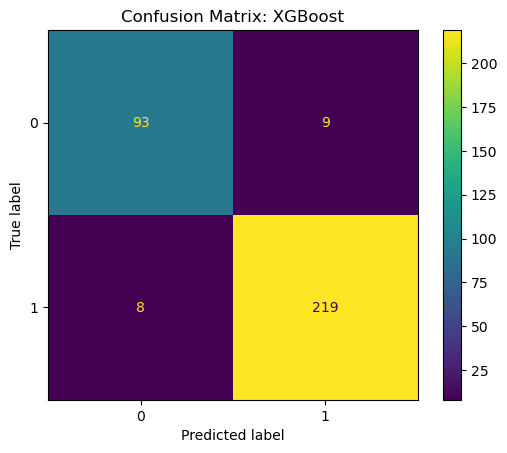

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       102
           1       0.96      0.96      0.96       227

    accuracy                           0.95       329
   macro avg       0.94      0.94      0.94       329
weighted avg       0.95      0.95      0.95       329


Evaluating MLPClassifier
Training Accuracy: 0.9712
Test Accuracy: 0.8936


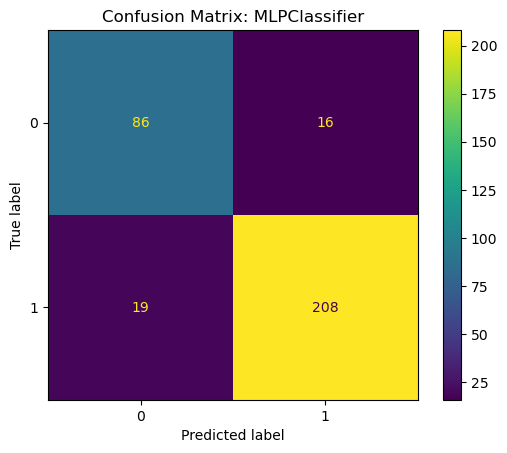

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       102
           1       0.93      0.92      0.92       227

    accuracy                           0.89       329
   macro avg       0.87      0.88      0.88       329
weighted avg       0.89      0.89      0.89       329


Evaluating LDA
Training Accuracy: 0.9982
Test Accuracy: 0.9453


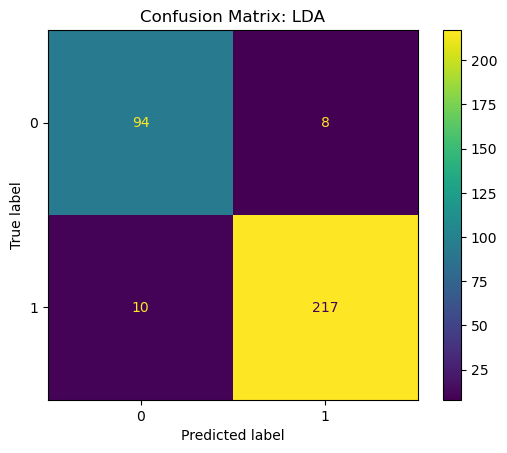

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       102
           1       0.96      0.96      0.96       227

    accuracy                           0.95       329
   macro avg       0.93      0.94      0.94       329
weighted avg       0.95      0.95      0.95       329


Evaluating LinearSVC
Training Accuracy: 0.9998
Test Accuracy: 0.9544


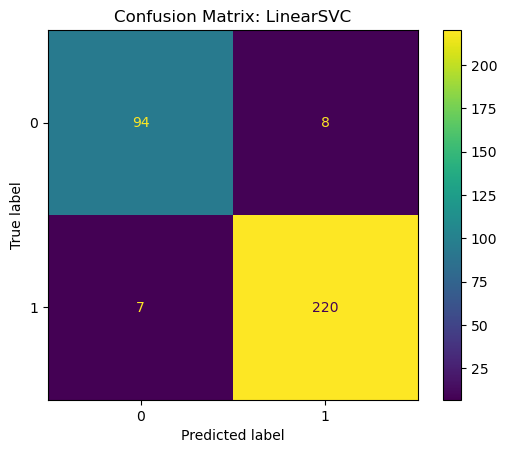

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       102
           1       0.96      0.97      0.97       227

    accuracy                           0.95       329
   macro avg       0.95      0.95      0.95       329
weighted avg       0.95      0.95      0.95       329


Evaluating LightGBM
Training Accuracy: 0.9998
Test Accuracy: 0.9422


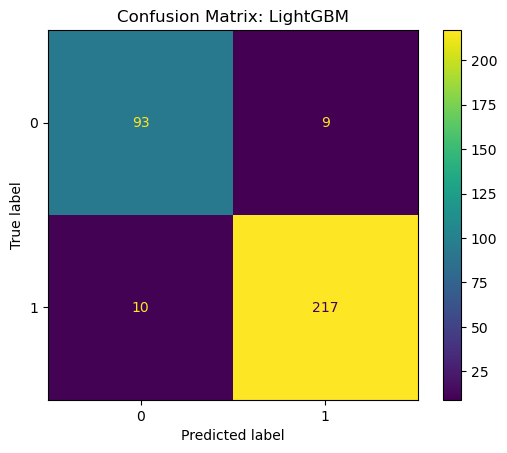

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       102
           1       0.96      0.96      0.96       227

    accuracy                           0.94       329
   macro avg       0.93      0.93      0.93       329
weighted avg       0.94      0.94      0.94       329


Evaluating HistGradientBoosting
Training Accuracy: 0.9998
Test Accuracy: 0.9514


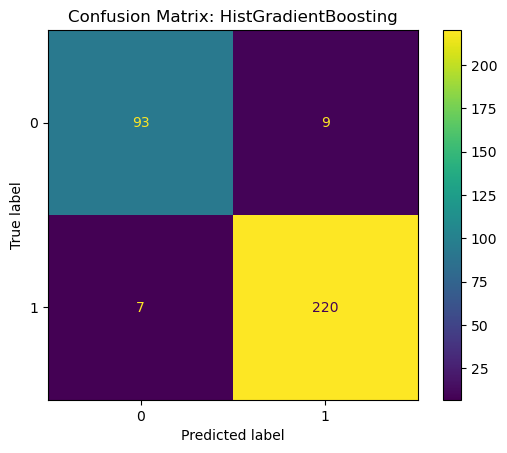

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       102
           1       0.96      0.97      0.96       227

    accuracy                           0.95       329
   macro avg       0.95      0.94      0.94       329
weighted avg       0.95      0.95      0.95       329


Evaluating RidgeClassifier
Training Accuracy: 0.9980
Test Accuracy: 0.9453


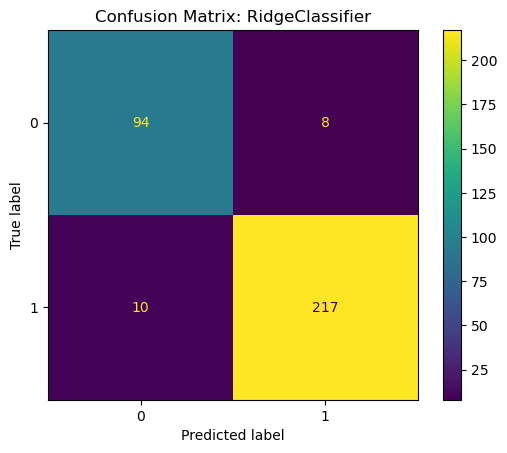

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       102
           1       0.96      0.96      0.96       227

    accuracy                           0.95       329
   macro avg       0.93      0.94      0.94       329
weighted avg       0.95      0.95      0.95       329


Average Metrics for Each Classifier:
             Classifier  Accuracy  Precision    Recall        F1
0          RandomForest  0.942249   0.940643  0.923059  0.931169
1            ExtraTrees  0.945289   0.940476  0.930660  0.935349
2    LogisticRegression  0.911854   0.894792  0.901032  0.897801
3               XGBoost  0.948328   0.940659  0.938261  0.939447
4         MLPClassifier  0.893617   0.873810  0.879718  0.876656
5                   LDA  0.945289   0.934145  0.938758  0.936399
6             LinearSVC  0.954407   0.947803  0.945366  0.946571
7              LightGBM  0.942249   0.931545  0.933856  0.932687
8  HistGradientBoosting  0.

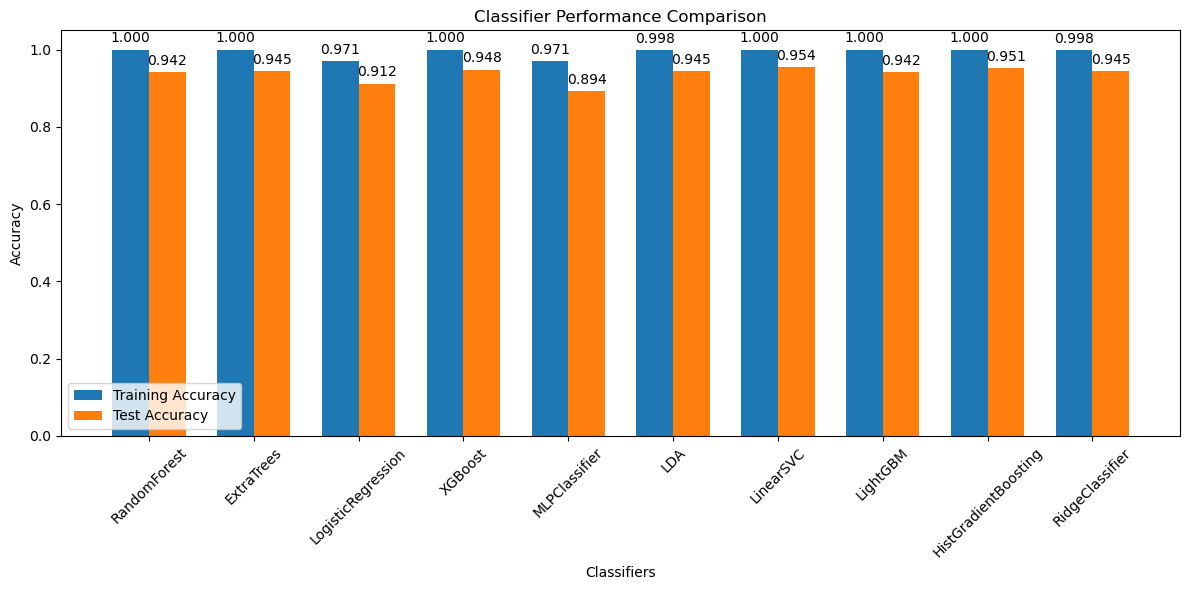

In [13]:
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, BaggingClassifier, VotingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, SGDClassifier,
    PassiveAggressiveClassifier, Perceptron
)
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from collections import Counter
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("Warning: CatBoost not installed. Run '!pip install catboost'")

most_frequent_label = Counter(y_train).most_common(1)[0][0]

classifiers = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=500),
    'LDA': LinearDiscriminantAnalysis(),
    'LinearSVC': LinearSVC(random_state=42, max_iter=200),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=100, random_state=42),
    'RidgeClassifier': RidgeClassifier(random_state=42),
}

results = {}
metrics_table = []
classification_reports = {}
figure_dir = 'harmony_results_figures'
os.makedirs(figure_dir, exist_ok=True)
figure_paths = []
confusion_matrix_paths = {}

for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {name}")
    print(f"{'='*50}")
    clf.fit(X_train, y_train)
    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    y_pred = clf.predict(X_test)
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix: {name}")
    figure_path = os.path.join(figure_dir, f'{name}_confusion_matrix.png')
    plt.savefig(figure_path, dpi=150, bbox_inches='tight')
    figure_paths.append(figure_path)
    confusion_matrix_paths[name] = figure_path
    plt.show()
    plt.close()
    print('Classification Report:')
    report_text = classification_report(y_test, y_pred, zero_division=0)
    print(report_text)
    classification_reports[name] = pd.DataFrame(
        classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    ).transpose().reset_index().rename(columns={'index': 'Class'})
    metrics_table.append({
        'Classifier': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1': f1_score(y_test, y_pred, average='macro', zero_division=0)
    })
    results[name] = {'train_accuracy': train_acc, 'test_accuracy': test_acc}

metrics_df = pd.DataFrame(metrics_table)
print("\nAverage Metrics for Each Classifier:")
print(metrics_df)

names = list(results.keys())
train_accuracies = [results[name]['train_accuracy'] for name in names]
test_accuracies = [results[name]['test_accuracy'] for name in names]
x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width / 2, train_accuracies, width, label='Training Accuracy')
rects2 = ax.bar(x + width / 2, test_accuracies, width, label='Test Accuracy')
ax.set_xlabel('Classifiers')
ax.set_ylabel('Accuracy')
ax.set_title('Classifier Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45)
ax.legend()

for rects in (rects1, rects2):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f'{height:.3f}',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom'
        )

plt.tight_layout()
comparison_path = os.path.join(figure_dir, 'classifier_accuracy_comparison.png')
plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
figure_paths.append(comparison_path)
plt.show()
plt.close()

In [ ]:
# Export metrics, classification reports, and all figures to one Excel workbook
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as ExcelImage

excel_path = 'harmony_classifier_reports_results.xlsx'

# Write the summary metrics and detailed reports.
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    metrics_df.to_excel(writer, sheet_name='Metrics', index=False)
    report_start_row = 0
    for classifier_name, report_df in classification_reports.items():
        writer_report = report_df.copy()
        writer_report.insert(0, 'Classifier', classifier_name)
        writer_report.to_excel(
            writer,
            sheet_name='Reports',
            startrow=report_start_row + 1,
            index=False
        )
        report_start_row += len(writer_report) + 3

# Add all figures to the workbook.
workbook = load_workbook(excel_path)
figures_sheet = workbook.create_sheet('Figures')
figures_sheet['A1'] = 'Classifier evaluation figures'

for figure_number, figure_path in enumerate(figure_paths, start=1):
    image = ExcelImage(figure_path)
    image.width = 720
    image.height = 430
    image.anchor = f'A{2 + (figure_number - 1) * 24}'
    figures_sheet.add_image(image)

# Pair each classifier's report with its confusion matrix in the Reports sheet.
reports_sheet = workbook['Reports']
report_row = 1
for classifier_name, report_df in classification_reports.items():
    report_rows = len(report_df) + 1
    reports_sheet.cell(row=report_row, column=7, value='Confusion Matrix')
    image = ExcelImage(confusion_matrix_paths[classifier_name])
    image.width = 520
    image.height = 320
    image.anchor = f'G{report_row + 1}'
    reports_sheet.add_image(image)
    report_row += report_rows + 3

for sheet in (workbook['Metrics'], workbook['Reports'], workbook['Figures']):
    sheet.freeze_panes = 'A2'

workbook.save(excel_path)
print(f'Excel results saved to: {os.path.abspath(excel_path)}')
print(f'Classification reports exported: {len(classification_reports)}')
print(f'Figures embedded: {len(figure_paths)}')